In [373]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [374]:
response = requests.get("https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2025-01-01&settlementDateTo=2026-03-01&settlementPeriod=3&settlementPeriod=4&fuelType=WIND")

actual = response.json()

In [375]:
response = requests.get("https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2024-12-30T00%3A00%3A00Z&publishDateTimeTo=2026-03-01T00%3A00%3A00Z")

forecast = response.json()

In [376]:
print(actual[:2])
print(forecast[:2])

[{'dataset': 'FUELHH', 'publishTime': '2026-03-01T02:00:00Z', 'startTime': '2026-03-01T01:30:00Z', 'settlementDate': '2026-03-01', 'settlementPeriod': 4, 'fuelType': 'WIND', 'generation': 10372}, {'dataset': 'FUELHH', 'publishTime': '2026-03-01T01:30:00Z', 'startTime': '2026-03-01T01:00:00Z', 'settlementDate': '2026-03-01', 'settlementPeriod': 3, 'fuelType': 'WIND', 'generation': 10087}]
[{'dataset': 'WINDFOR', 'publishTime': '2026-02-28T22:30:00Z', 'startTime': '2026-02-27T21:00:00Z', 'generation': 6997}, {'dataset': 'WINDFOR', 'publishTime': '2026-02-28T22:30:00Z', 'startTime': '2026-02-27T22:00:00Z', 'generation': 7146}]


In [377]:
actual_df = pd.DataFrame(actual)
forecast_df = pd.DataFrame(forecast)

In [378]:
actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2026-03-01T02:00:00Z,2026-03-01T01:30:00Z,2026-03-01,4,WIND,10372
1,FUELHH,2026-03-01T01:30:00Z,2026-03-01T01:00:00Z,2026-03-01,3,WIND,10087
2,FUELHH,2026-02-28T02:00:00Z,2026-02-28T01:30:00Z,2026-02-28,4,WIND,5907
3,FUELHH,2026-02-28T01:30:00Z,2026-02-28T01:00:00Z,2026-02-28,3,WIND,5630
4,FUELHH,2026-02-27T02:00:00Z,2026-02-27T01:30:00Z,2026-02-27,4,WIND,13886


In [379]:
forecast_df.head()

,dataset,publishTime,startTime,generation
0,WINDFOR,2026-02-28T22:30:00Z,2026-02-27T21:00:00Z,6997
1,WINDFOR,2026-02-28T22:30:00Z,2026-02-27T22:00:00Z,7146
2,WINDFOR,2026-02-28T22:30:00Z,2026-02-27T23:00:00Z,6725
3,WINDFOR,2026-02-28T22:30:00Z,2026-02-28T00:00:00Z,6392
4,WINDFOR,2026-02-28T22:30:00Z,2026-02-28T01:00:00Z,6538


In [380]:
# Converting time string to pandas datetime, horizon calculation and passing filtering only required columns
def preprocess_actual(df):
  df = df.copy()
  df['startTime'] = pd.to_datetime(df['startTime'])
  return df[['startTime','generation']]

def preprocess_forecast(df):
  df = df.copy()
  df['startTime'] = pd.to_datetime(df['startTime'])
  df['publishTime'] = pd.to_datetime(df['publishTime'])
  df['horizon'] = (df['startTime'] - df['publishTime']).dt.total_seconds()/3600
  return df[['startTime','publishTime','horizon', 'generation']]

In [381]:
actual = preprocess_actual(actual_df).reset_index()
forecast = preprocess_forecast(forecast_df).reset_index()

In [382]:
actual = actual.sort_values('startTime')
forecast = forecast.sort_values('startTime')

In [383]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None) # Show all columns

In [384]:
print("Actual Length: ", len(actual))
print("Forecast Length: ", len(forecast))

Actual Length:  850
Forecast Length:  248638


In [385]:
actual.head()

,index,startTime,generation
849,849,2025-01-01 01:00:00+00:00,14992
848,848,2025-01-01 01:30:00+00:00,14580
847,847,2025-01-02 01:00:00+00:00,7494
846,846,2025-01-02 01:30:00+00:00,7940
845,845,2025-01-03 01:00:00+00:00,12992


In [386]:
forecast.head()

,index,startTime,publishTime,horizon,generation
248565,248565,2024-12-29 21:00:00+00:00,2024-12-30 02:30:00+00:00,-5.5,15025
248054,248054,2024-12-29 21:00:00+00:00,2024-12-30 22:30:00+00:00,-25.5,15025
248273,248273,2024-12-29 21:00:00+00:00,2024-12-30 11:30:00+00:00,-14.5,15025
248200,248200,2024-12-29 21:00:00+00:00,2024-12-30 15:30:00+00:00,-18.5,15025
248492,248492,2024-12-29 21:00:00+00:00,2024-12-30 04:30:00+00:00,-7.5,15025


In [387]:
sample = forecast.groupby('startTime')['horizon'].max()
pos_length = len(forecast[forecast['horizon'] >= 0])
neg_length = len(forecast) - pos_length

print('Positive Horizon: ', pos_length)
print('Negative Horizon: ', neg_length)

# Assuming I need to calulate max(publishTime) s.t. startTime - publishTime >= horizon

Positive Horizon:  194182
Negative Horizon:  54456


In [388]:
example = [{'t' : '2026-03-23T01:30:00Z', 'g' : 2}, {'t' : '2026-03-23T01:30:00Z', 'g' : 5}, {'t' : '2026-03-23T01:00:00Z', 'g' : 10}, {'t' : '2026-03-23T02:00:00Z', 'g' : 1}, {'t' : '2026-03-23T02:30:00Z', 'g' : 3}]
example_df = pd.DataFrame(example)

example_df['t'] = pd.to_datetime(example_df['t'])
example_df



,t,g
0,2026-03-23 01:30:00+00:00,2
1,2026-03-23 01:30:00+00:00,5
2,2026-03-23 01:00:00+00:00,10
3,2026-03-23 02:00:00+00:00,1
4,2026-03-23 02:30:00+00:00,3


In [389]:
example_df['t'] = example_df['t'].dt.floor('h')
example_df

,t,g
0,2026-03-23 01:00:00+00:00,2
1,2026-03-23 01:00:00+00:00,5
2,2026-03-23 01:00:00+00:00,10
3,2026-03-23 02:00:00+00:00,1
4,2026-03-23 02:00:00+00:00,3


In [390]:
example_df = example_df.groupby('t')['g'].mean().reset_index()
example_df

,t,g
0,2026-03-23 01:00:00+00:00,5.666667
1,2026-03-23 02:00:00+00:00,2.000000


In [391]:
# Actual generation is 30 minutes resolution and forecast generation is 1hr
# Rounding off actual generation time and taking mean of generation which have same timestamp to avoid loss of data
actual['startTime'] = actual['startTime'].dt.floor('h')

actual = actual.groupby('startTime').mean().reset_index()

In [392]:
actual.head()

,startTime,index,generation
0,2025-01-01 01:00:00+00:00,848.5,14786.0
1,2025-01-02 01:00:00+00:00,846.5,7717.0
2,2025-01-03 01:00:00+00:00,844.5,13045.5
3,2025-01-04 01:00:00+00:00,842.5,2595.0
4,2025-01-05 01:00:00+00:00,840.5,8834.0


In [393]:
table1 = pd.DataFrame({
    't' : [1, 2, 3, 4],
    'g' : [2, 4, 6, None]
})

table2 = pd.DataFrame({
    't' : [1, 1, 1, 2, 4, 5],
    'p' : [1.1, 1.4, 1.5, 2.5,  4.5, 6],
    'g' : [2, 3, 5, None, 8, 7]
})

In [394]:
table1

,t,g
0,1,2.0
1,2,4.0
2,3,6.0
3,4,NaN


In [395]:
table2

,t,p,g
0,1,1.1,2.0
1,1,1.4,3.0
2,1,1.5,5.0
3,2,2.5,NaN
4,4,4.5,8.0
5,5,6.0,7.0


In [396]:
table2['d'] = table2['p'] - table2['t']
table2 = table2[table2['d'] >= 0.5].copy()

idx = table2.groupby('t')['p'].idxmin()
table2 = table2.loc[idx]

table = pd.merge(table1, table2, on = 't')
table

,t,g_x,p,g_y,d
0,1,2.0,1.5,5.0,0.5
1,2,4.0,2.5,NaN,0.5
2,4,NaN,4.5,8.0,0.5


In [397]:
# Trying for all variations of horizons
horizon_pts = [4, 8, 16, 32]
horizon_pls = [float(h) for h in horizon_pts]

In [398]:
print(forecast['horizon'].dtype)

float64


In [399]:
def forecast_merge(h):
  temp_forecast = None
  # Only consider rows with horizon greater than h
  temp_forecast = forecast[forecast['horizon'] >= h].copy()

  # Group By startTime then take minimun of each group
  temp_idx = temp_forecast.groupby('startTime')['publishTime'].idxmax()

  # Filtering rows by temp_idx
  # Applying Inner joins to get the desied merged table
  temp_forecast = temp_forecast.loc[temp_idx]
  temp_forecast = pd.merge(actual, temp_forecast, on = 'startTime', how = 'left')

  if temp_forecast.empty:
    print("Forecast is empty")
    return

  return temp_forecast

def forecast_plot(h):
  temp_forecast = forecast_merge(h)

  # Collect x_axis, y_axis_actual and y_axis_forecast from table
  x_actual = temp_forecast['startTime']
  y_actual = temp_forecast['generation_x']
  y_forecast = temp_forecast['generation_y']

  plt.figure(figsize=(15,7))
  plt.plot(x_actual, y_actual, label='Actual')
  plt.plot(x_actual, y_forecast, label='forecast')
  plt.xlabel('Time')
  plt.ylabel('Generation')
  plt.title('Actual vs Forecast Generation')
  plt.legend()
  plt.show()

  errors = y_actual - y_forecast
  errors = errors.abs()
  print('Max Error:', errors.max())
  print('Min Error:', errors.min())
  print('Mean Error:', errors.mean())
  print('Median Error:', errors.median())
  print('p99 Error:', errors.quantile(0.99))

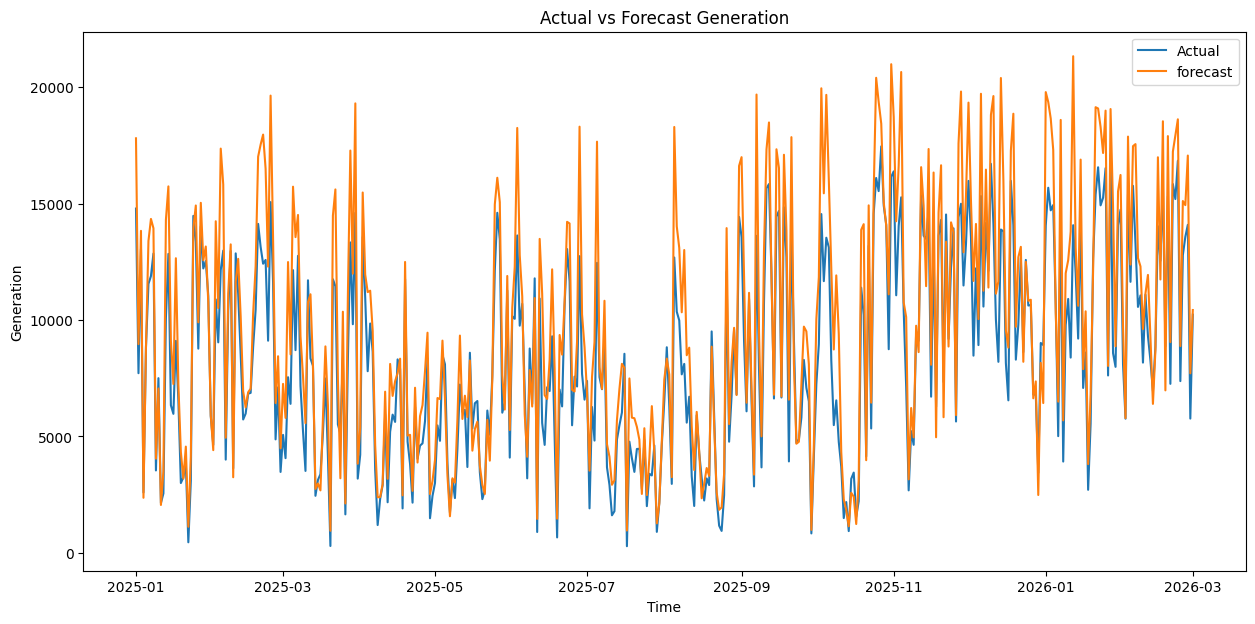

Max Error: 7256.0
Min Error: 13.0
Mean Error: 1690.5258823529412
Median Error: 1330.5
p99 Error: 5986.239999999997


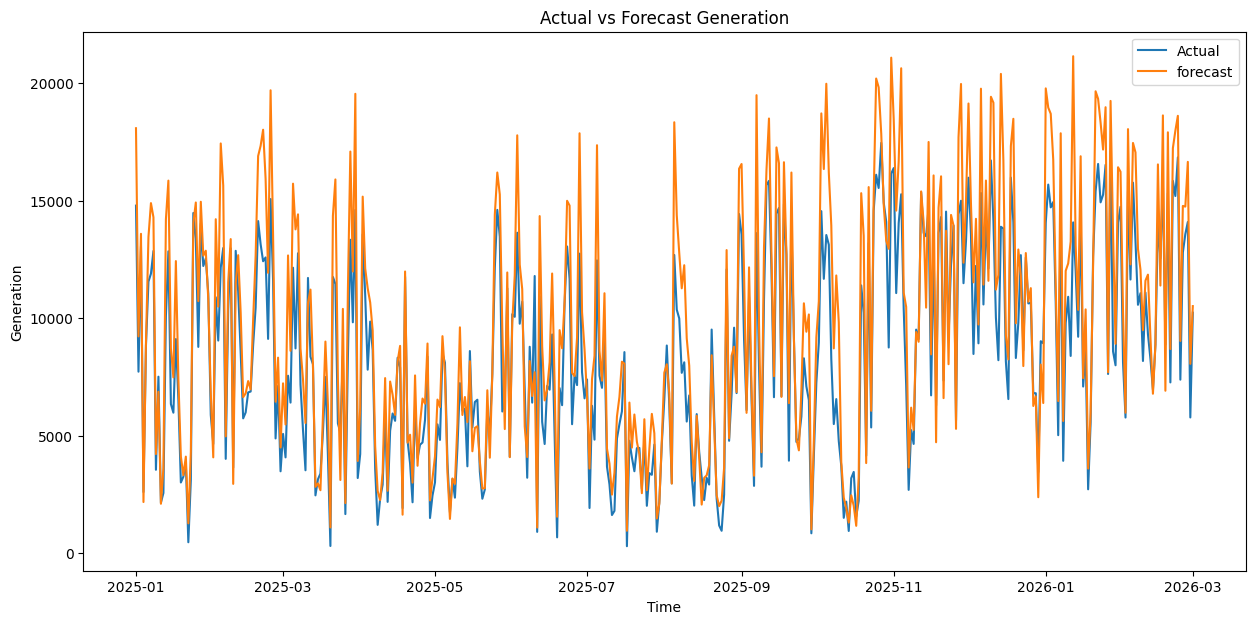

Max Error: 7073.0
Min Error: 0.5
Mean Error: 1672.8811764705883
Median Error: 1198.0
p99 Error: 5710.5


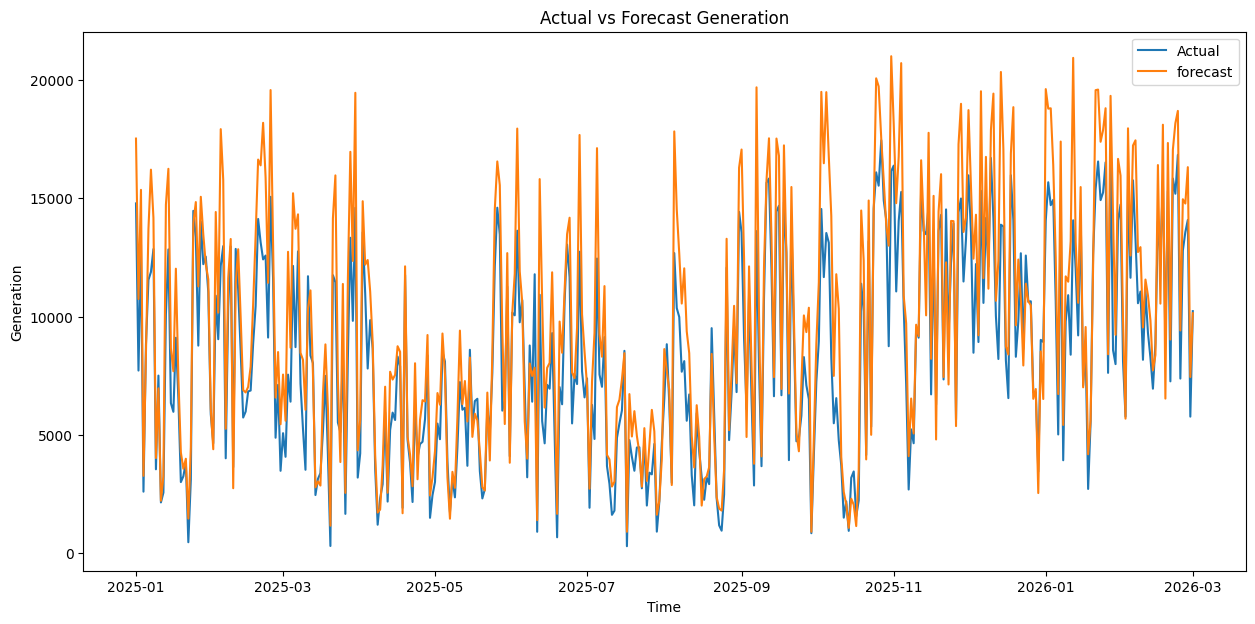

Max Error: 6870.0
Min Error: 15.5
Mean Error: 1732.189411764706
Median Error: 1323.0
p99 Error: 5915.039999999998


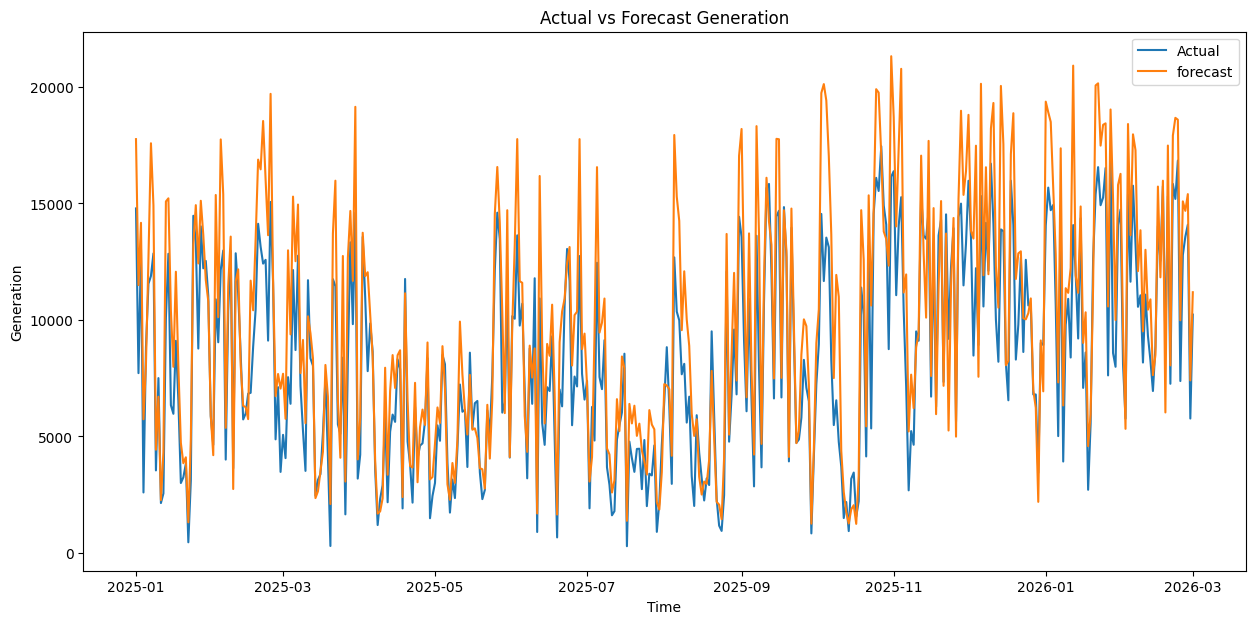

Max Error: 8455.0
Min Error: 6.0
Mean Error: 1901.2105882352942
Median Error: 1507.0
p99 Error: 6150.24


In [400]:
for h in horizon_pts:
  forecast_plot(h)

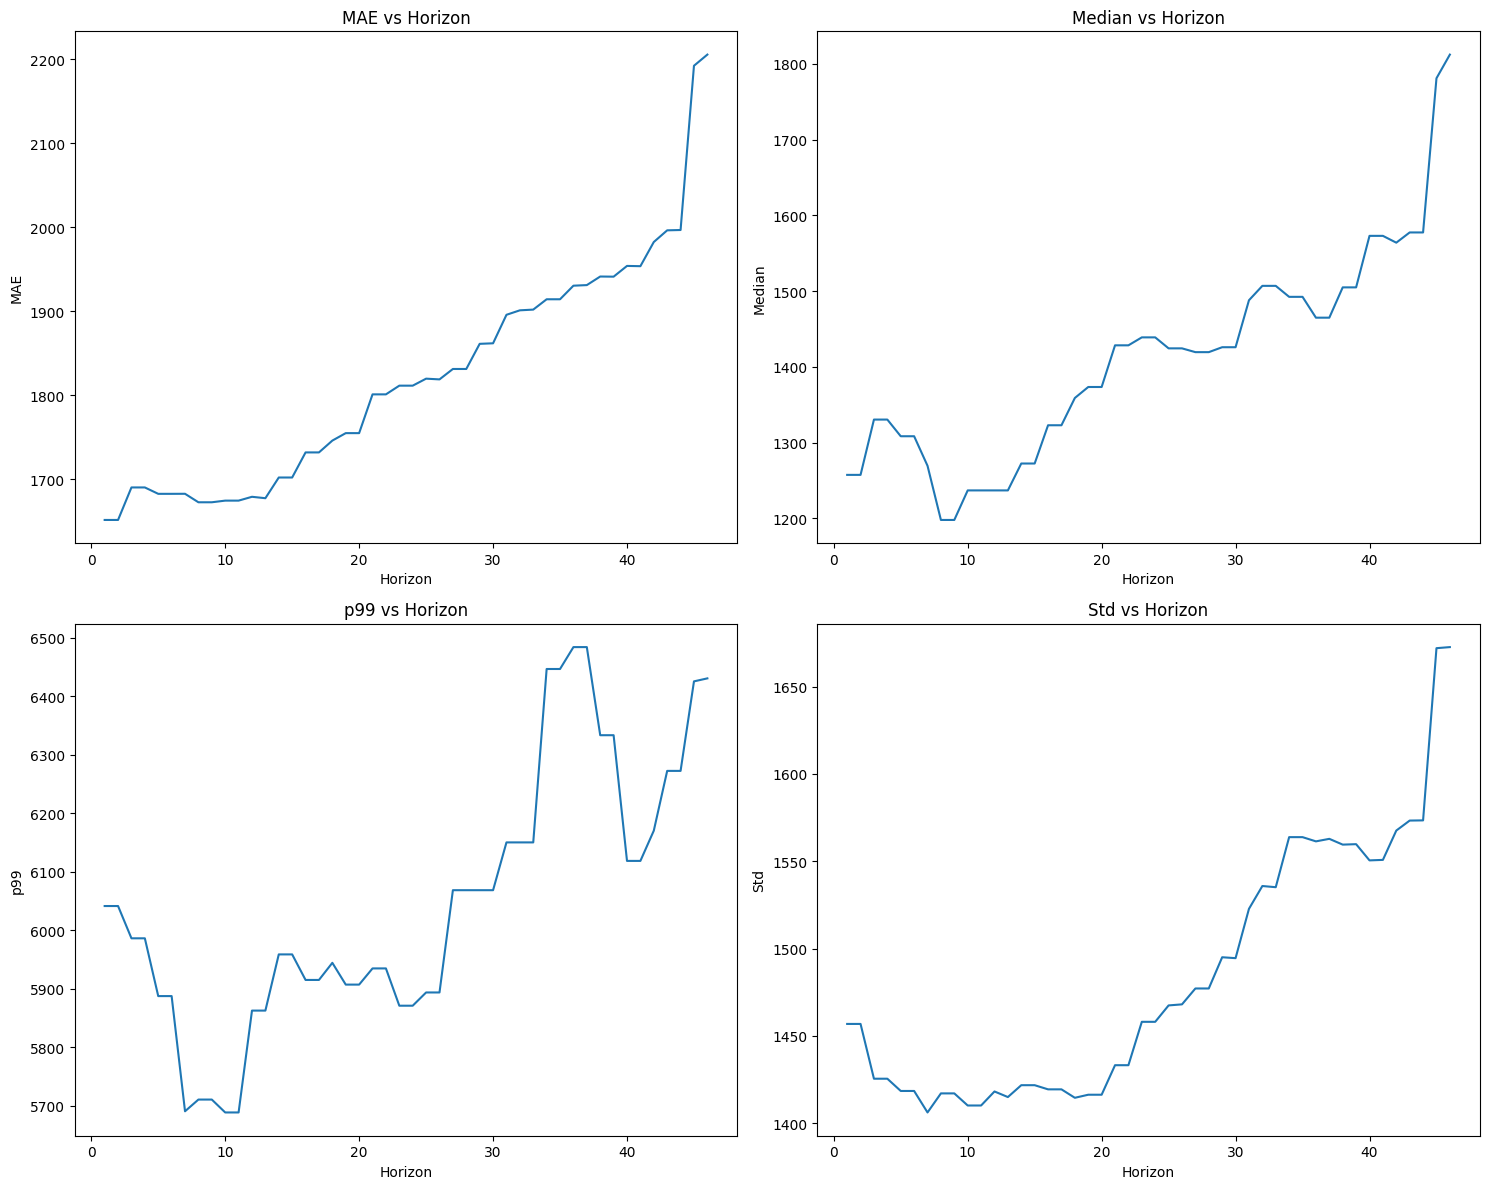

In [401]:
x_h = [float(h) for h in range(1, 49)]
names_t = ['MAE vs Horizon', 'Median vs Horizon', 'p99 vs Horizon', 'Std vs Horizon']
names_y = ['MAE', 'Median', 'p99', 'Std']
y_mae = []
y_med = []
y_p99 = []
y_std = []

for h in x_h:
  df = forecast_merge(h)
  df = (df['generation_x'] - df['generation_y']).abs()

  mae = df.mean()
  med = df.median()
  p99 = df.quantile(0.99)
  std = df.std()

  y_mae.append(mae)
  y_med.append(med)
  y_p99.append(p99)
  y_std.append(std)

y_final = [y_mae, y_med, y_p99, y_std]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes_flat = axes.flatten()

for k in range(4):
    axes_flat[k].plot(x_h, y_final[k])
    axes_flat[k].set_title(names_t[k])
    axes_flat[k].set_xlabel('Horizon')
    axes_flat[k].set_ylabel(names_y[k])
    k+=1

plt.tight_layout()
plt.show()



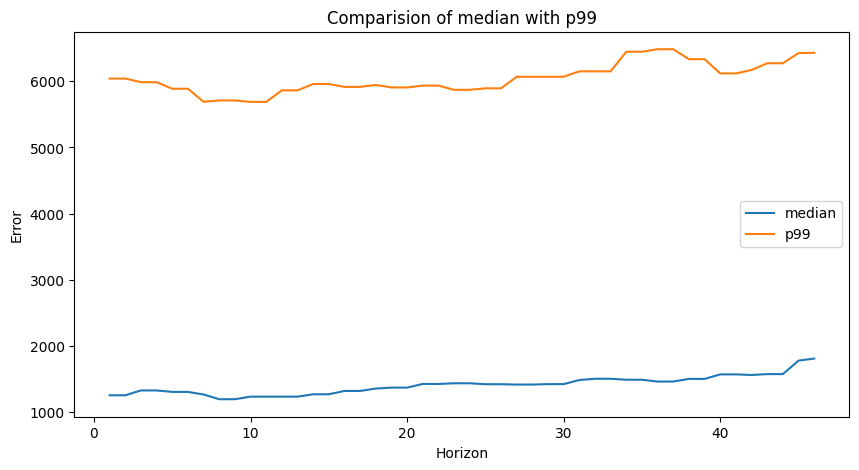

In [402]:
# Comparision of 1% fail (p99) with median
plt.figure(figsize=(10,5))
plt.plot(x_h, y_med, label='median')
plt.plot(x_h, y_p99, label='p99')
plt.title('Comparision of median with p99')
plt.xlabel('Horizon')
plt.ylabel('Error')
plt.legend()
plt.show()

In [403]:
# Conclusion
# As horizon increases it can be seen that model performance decrease because mae showing increasing
# Accuracy decreases as MAE increase
# Precision decreases as Std increases
# Error increases as Median increases
# p99 and median have huge difference for all horizon values